# Sequential Forecasting: Horizon Predictions

For three held-out test experiments, observed data (black scatter) with model
forecasts at 1, 2, 4, and 8 hours ahead of a mid-experiment cutoff point.

In [5]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AUTOMATION_DIR = Path.cwd()
while not (AUTOMATION_DIR / 'sequential_forecasting' / 'artifacts').exists():
    AUTOMATION_DIR = AUTOMATION_DIR.parent
    if AUTOMATION_DIR == AUTOMATION_DIR.parent:
        raise FileNotFoundError('Could not locate automation directory')
sys.path.insert(0, str(AUTOMATION_DIR))

from sequential_forecasting.data.observations import flatten_monomer_rows
from sequential_forecasting.data.contract import TIME_COLUMN, AREA_COLUMN

ARTIFACT_DIR = AUTOMATION_DIR / 'sequential_forecasting' / 'artifacts' / 'phase0'

records = []
with (ARTIFACT_DIR / 'inference' / 'predictions.jsonl').open(encoding='utf-8') as f:
    for line in f:
        r = json.loads(line)
        if r['assignment'] == 'test':
            records.append(r)

print(f'Loaded {len(records)} test-set forecasts across '
      f'{len(set(r["experiment_id"] for r in records))} experiments')

Loaded 2312 test-set forecasts across 49 experiments


Merged 20 monomer timestamp collisions


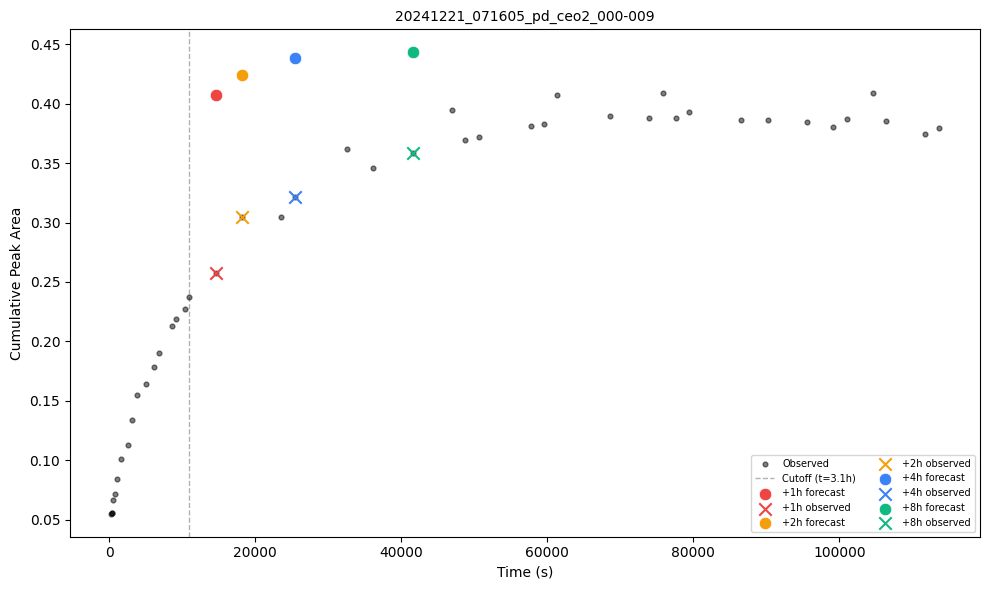

Merged 20 monomer timestamp collisions


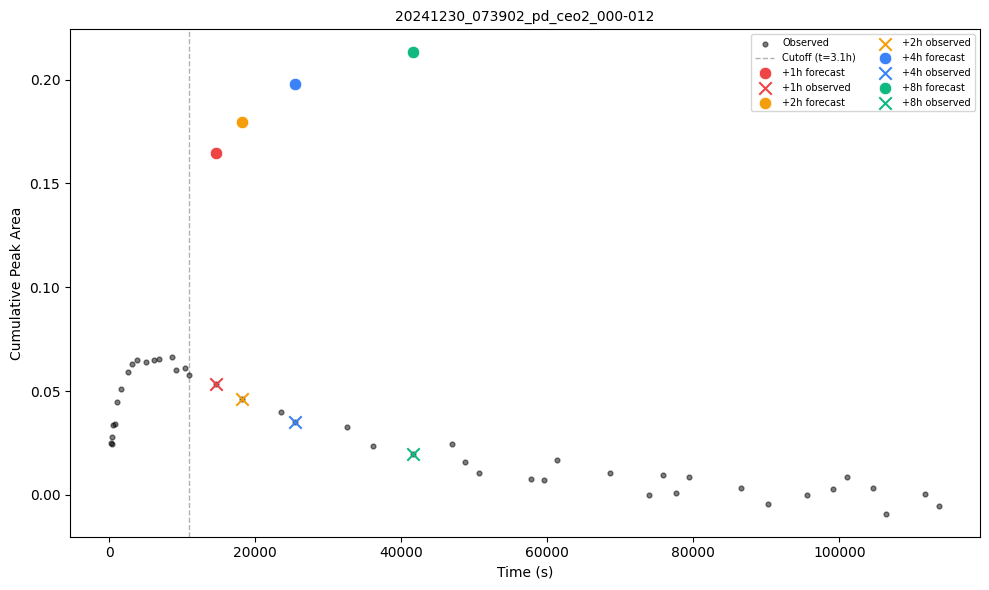

Merged 20 monomer timestamp collisions


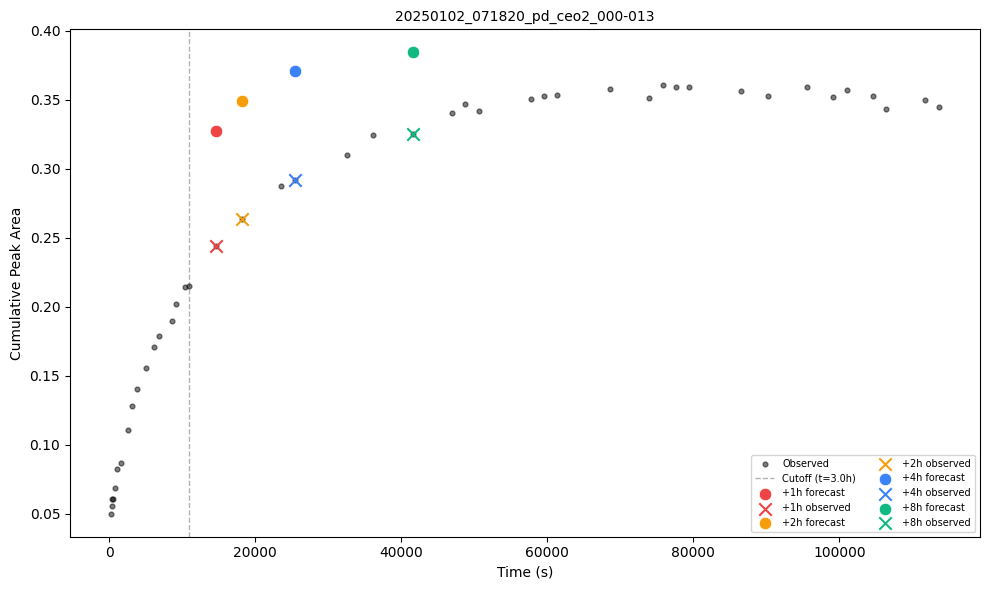

In [6]:
HORIZON_HOURS = [1, 2, 4, 8]
HORIZON_COLORS = {1: '#ef4444', 2: '#f59e0b', 4: '#3b82f6', 8: '#10b981'}
CUTOFF_FRACTION = 0.10  # mid-experiment cutoff so 8h ahead is visible

def load_observed(csv_path, final_time_s):
    df = pd.read_csv(csv_path)
    flat, _ = flatten_monomer_rows(df)
    timeline = flat[flat[TIME_COLUMN] <= final_time_s]
    return timeline[TIME_COLUMN].to_numpy(float), timeline[AREA_COLUMN].to_numpy(float)

def find_cutoff_record(exp_records, target_time):
    return min(exp_records, key=lambda r: abs(r['cutoff_time_s'] - target_time))

def nearest_index(times, target):
    return int(np.argmin(np.abs(times - target)))

experiments = sorted(set(r['experiment_id'] for r in records))
selected = experiments[:3]

for exp_id in selected:
    exp_records = sorted([r for r in records if r['experiment_id'] == exp_id],
                         key=lambda r: r['cutoff_time_s'])
    final_time = exp_records[0]['final_time_s']
    obs_t, obs_a = load_observed(exp_records[0]['csv_path'], final_time)

    cutoff_target = CUTOFF_FRACTION * final_time
    rec = find_cutoff_record(exp_records, cutoff_target)
    ct = rec['cutoff_time_s']
    curve_t = np.array(rec['curve_times_s'], float)
    curve_a = np.array(rec['curve_predicted_area'], float)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(obs_t, obs_a, c='black', s=12, alpha=0.5, label='Observed', zorder=5)
    ax.axvline(ct, color='gray', linestyle='--', linewidth=1, alpha=0.6, label=f'Cutoff (t={ct/3600:.1f}h)')

    for hours in HORIZON_HOURS:
        target = ct + hours * 3600
        if target > final_time:
            continue
        idx = nearest_index(curve_t, target)
        ax.scatter([curve_t[idx]], [curve_a[idx]], c=HORIZON_COLORS[hours],
                   s=80, zorder=6, edgecolors='white', linewidth=0.5,
                   label=f'+{hours}h forecast')
        obs_idx = nearest_index(obs_t, target)
        ax.scatter([obs_t[obs_idx]], [obs_a[obs_idx]], c=HORIZON_COLORS[hours],
                   s=80, zorder=6, marker='x',
                   label=f'+{hours}h observed')

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Cumulative Peak Area')
    ax.set_title(exp_id, fontsize=10)
    ax.legend(loc='best', fontsize=7, ncol=2)
    fig.tight_layout()
    plt.show()